# Building Evidence for Retrieval Quality

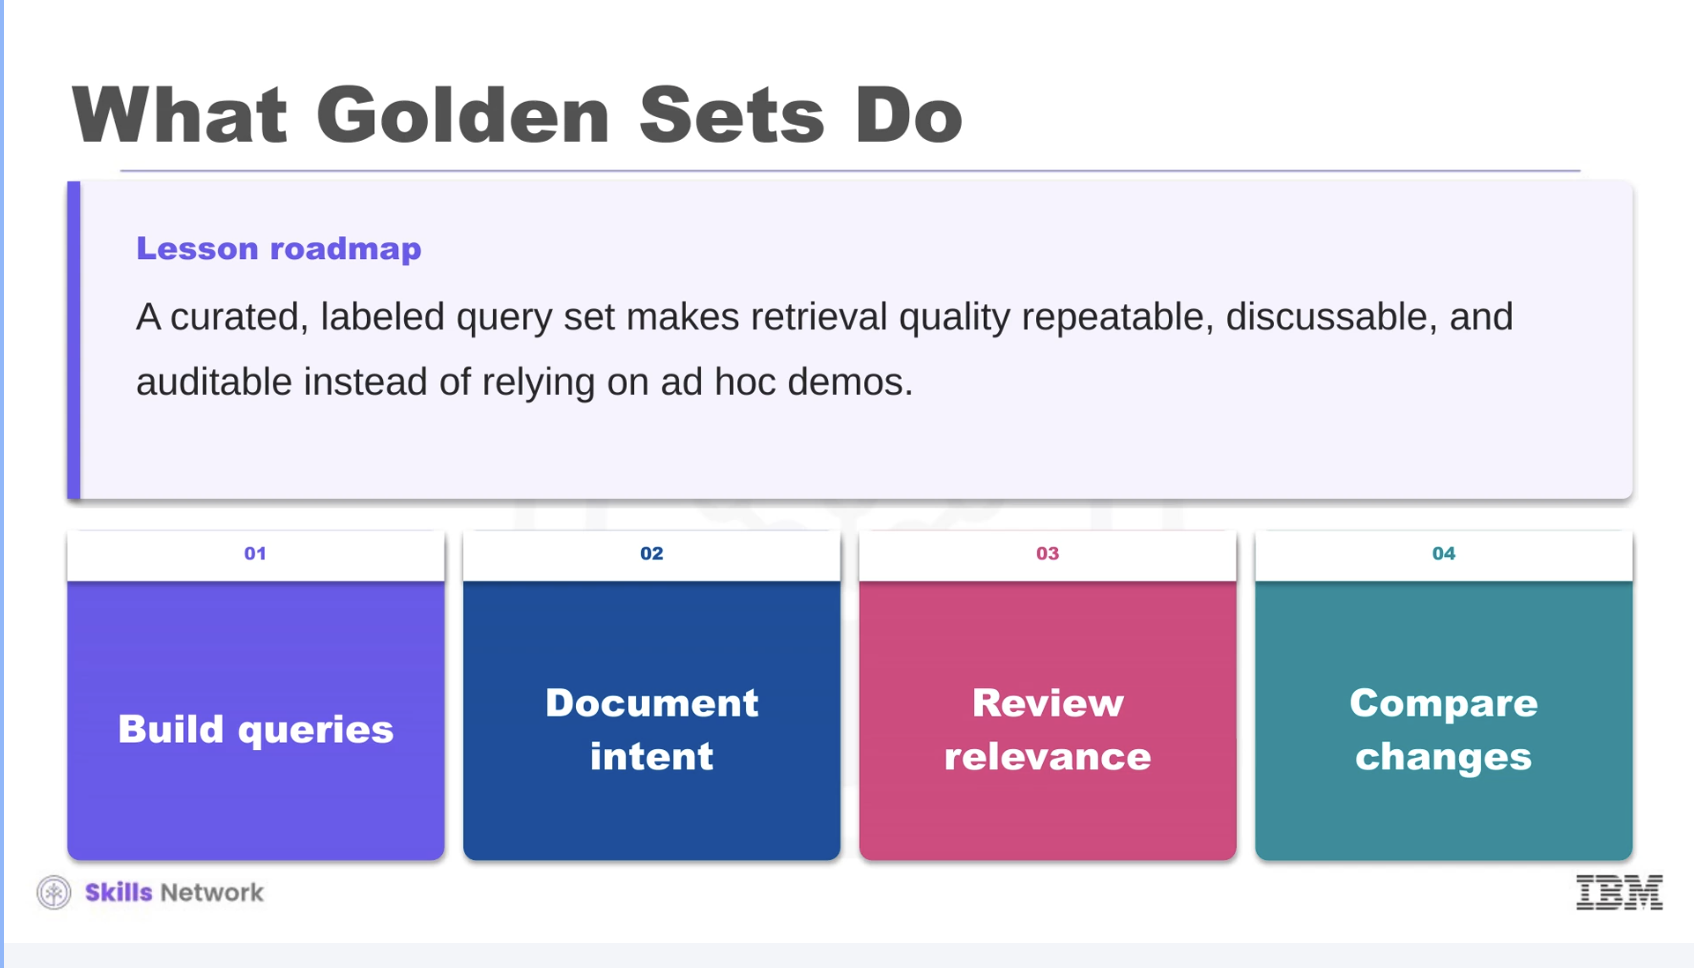
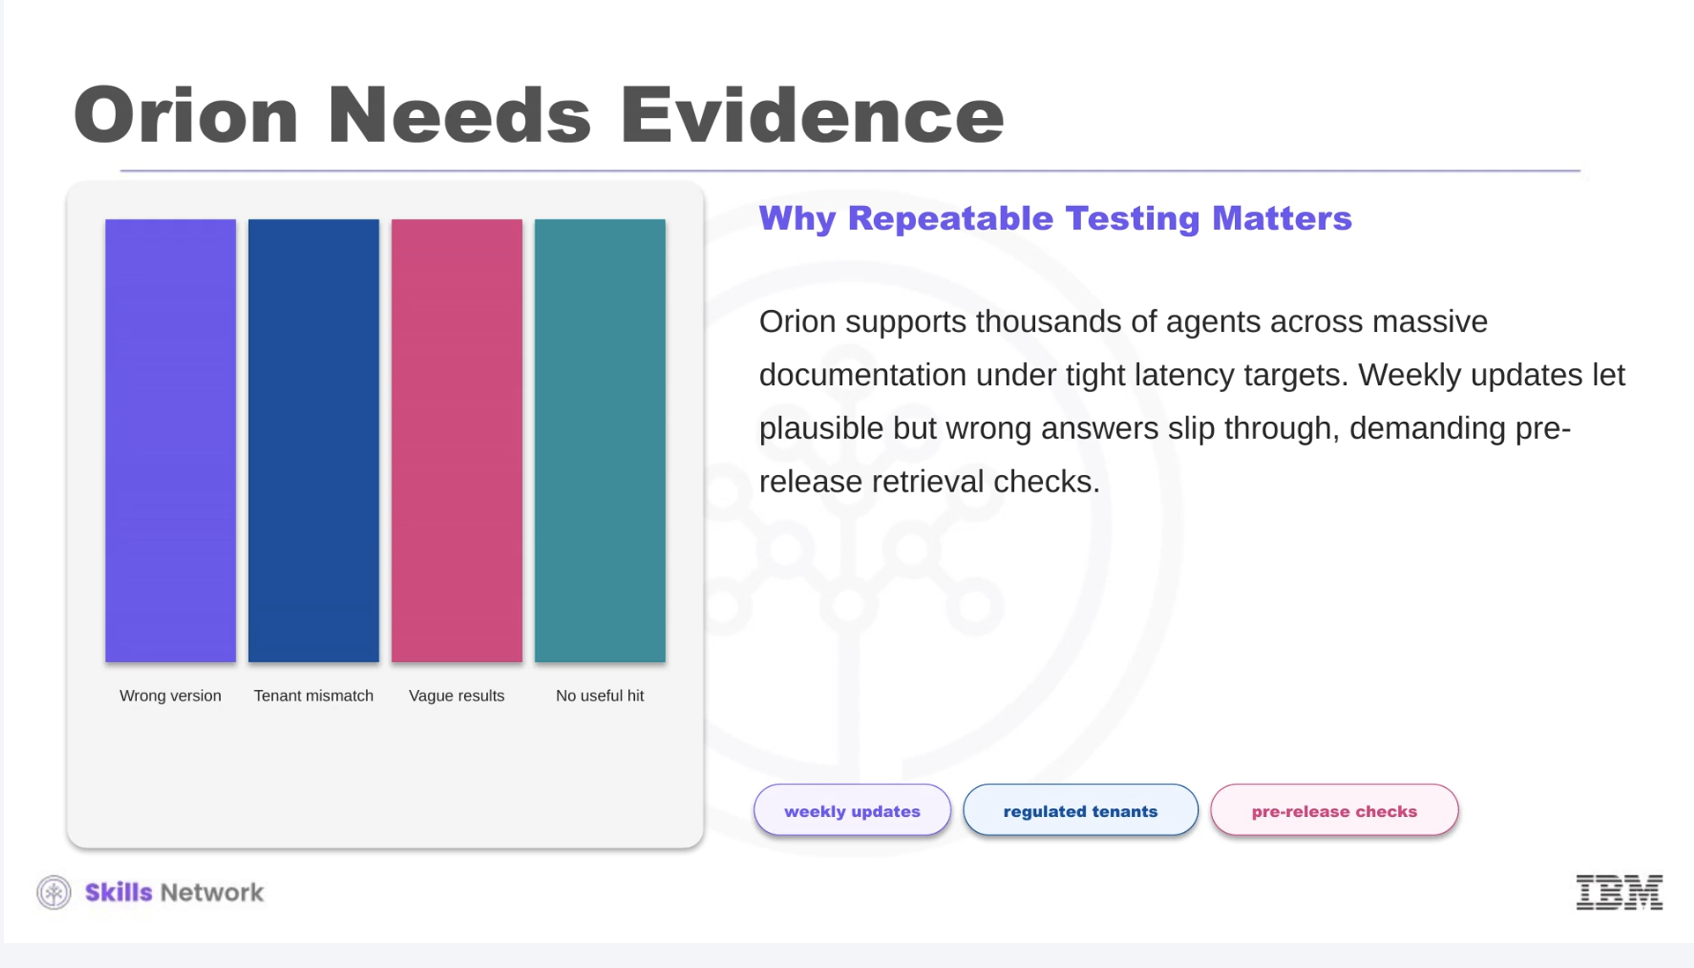
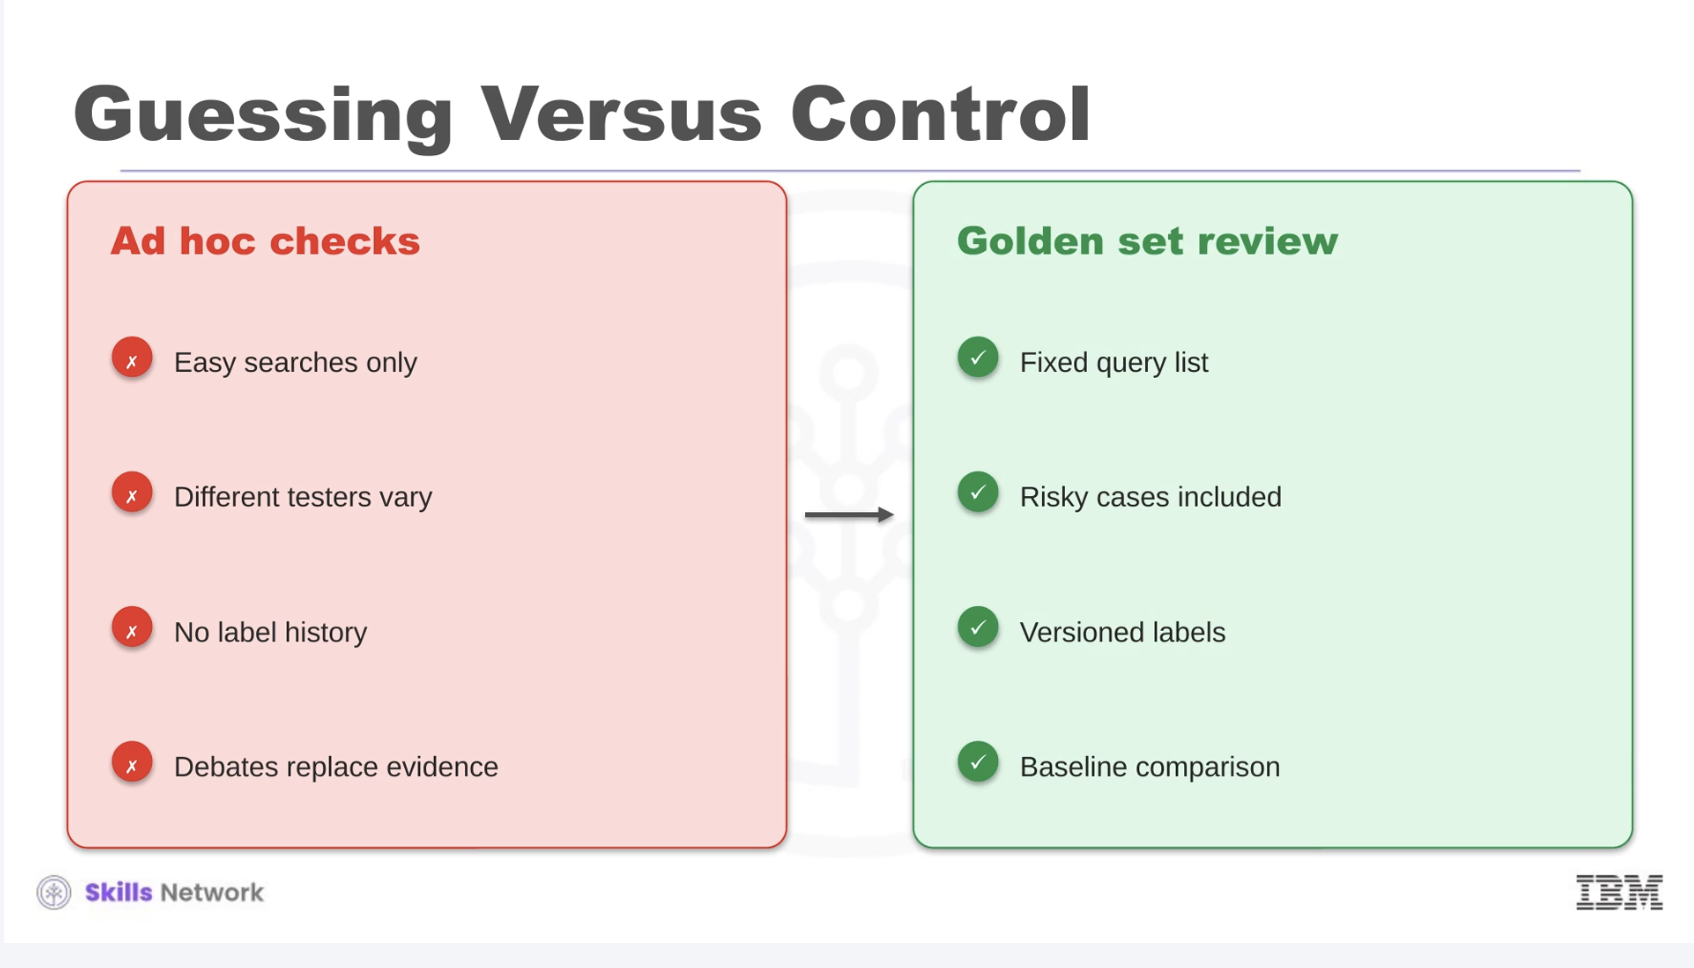
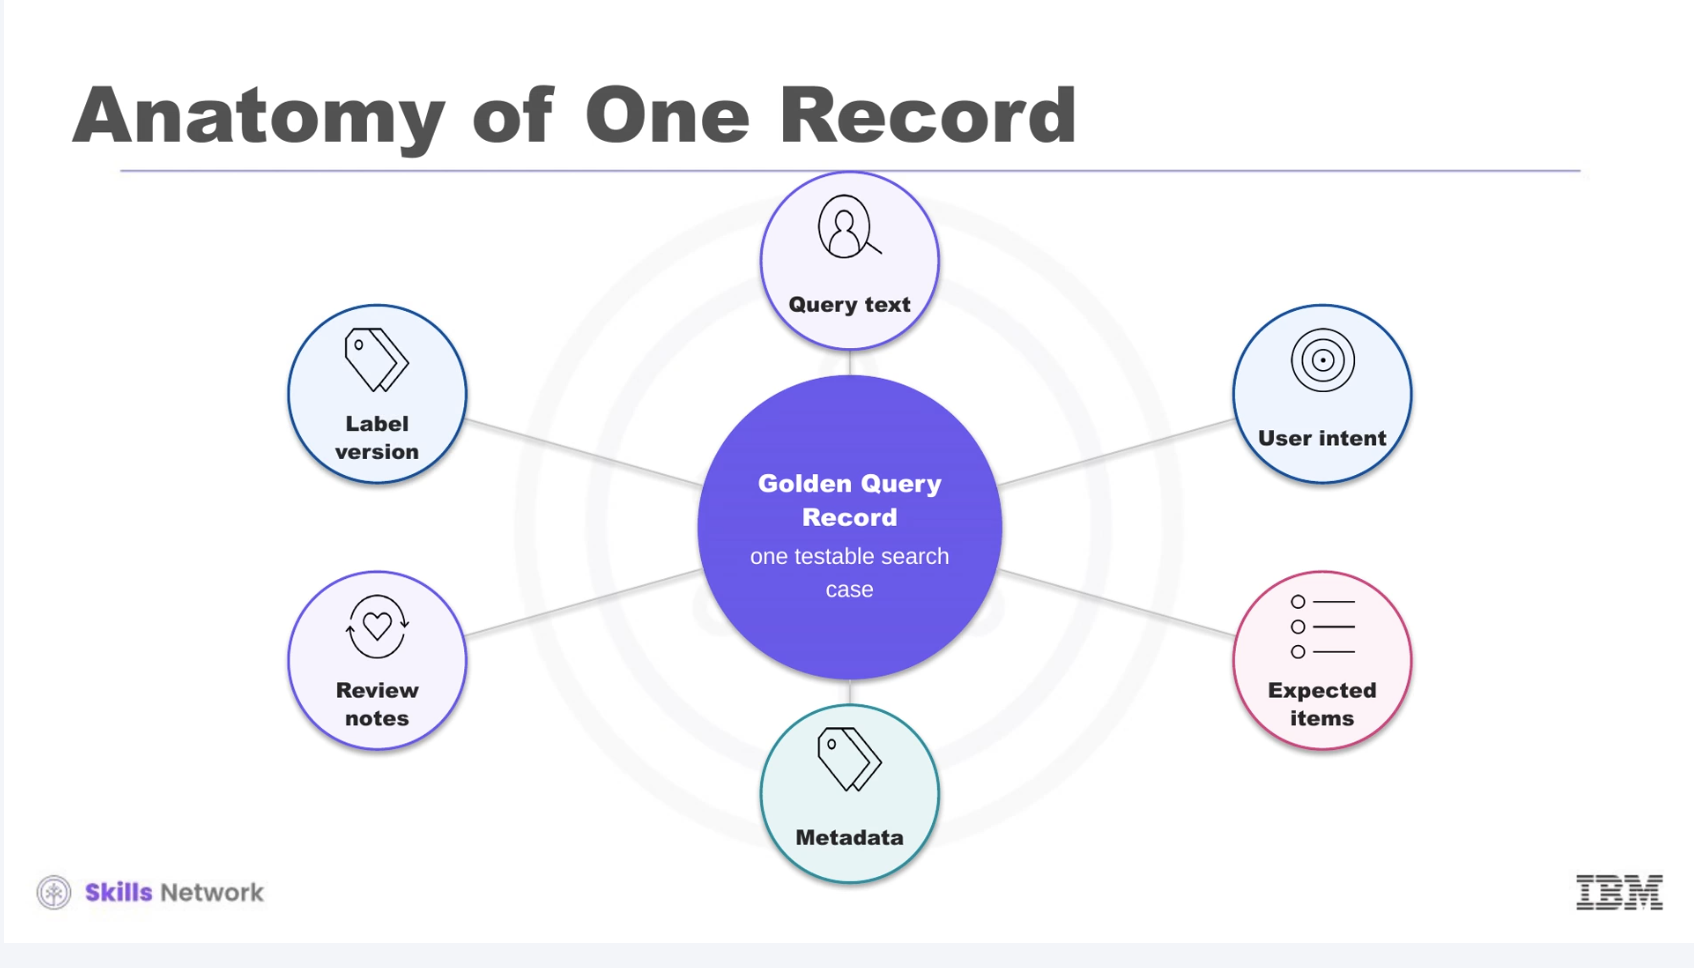
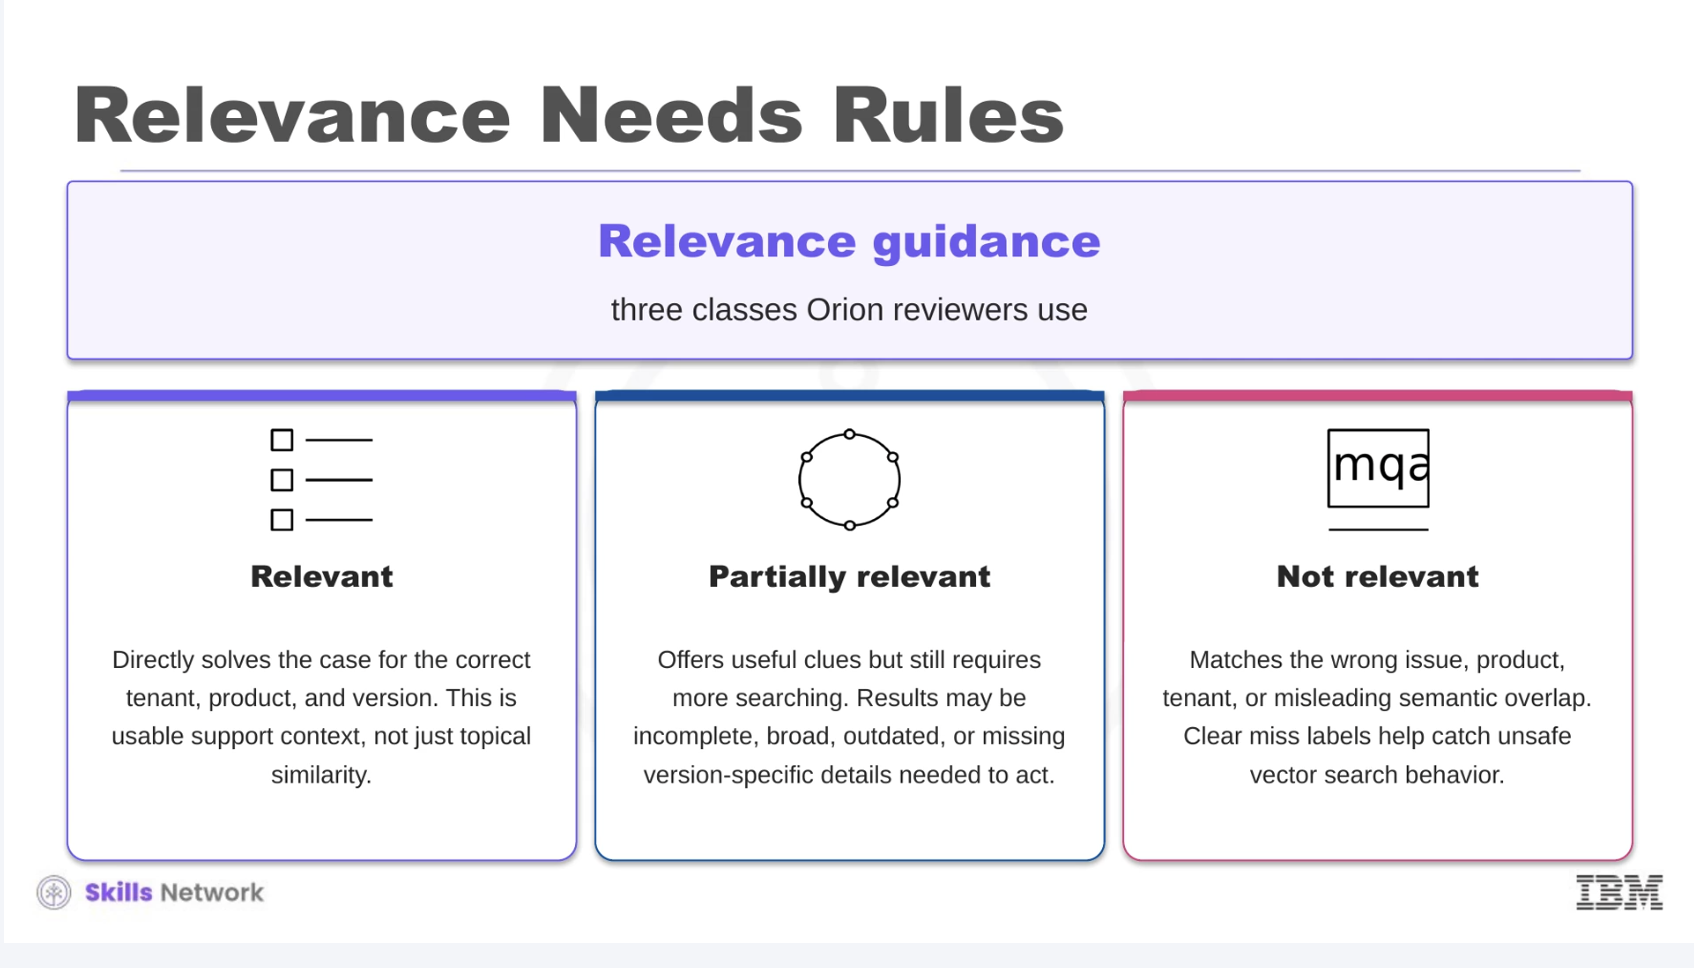
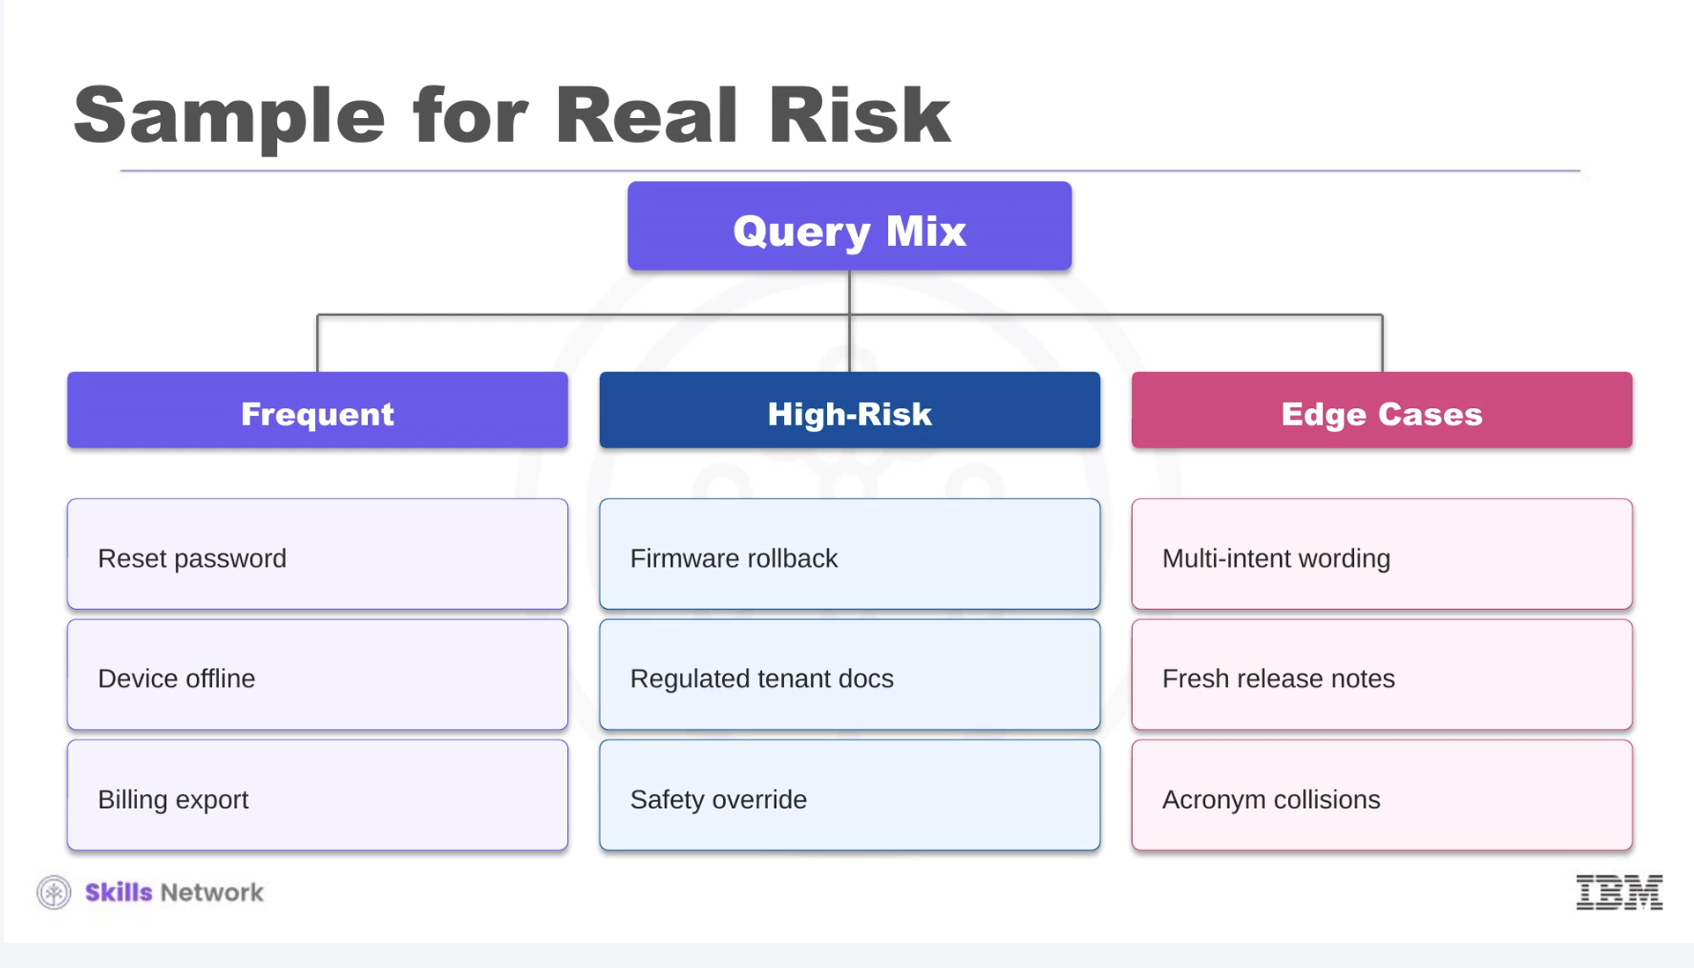
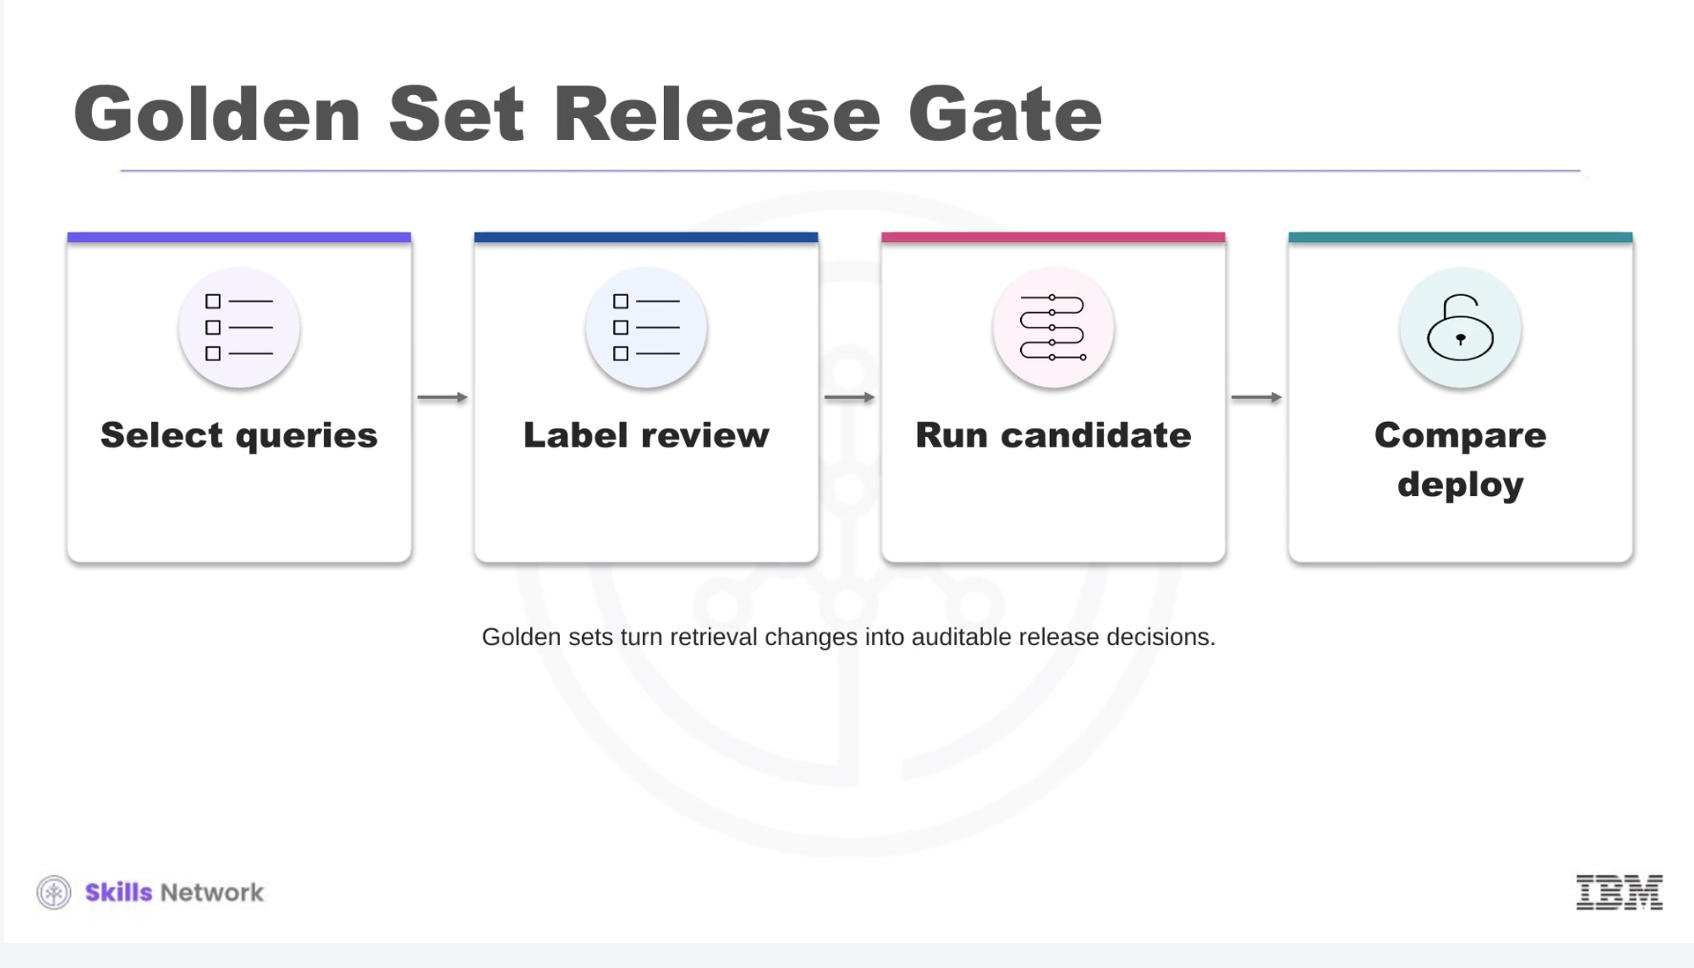
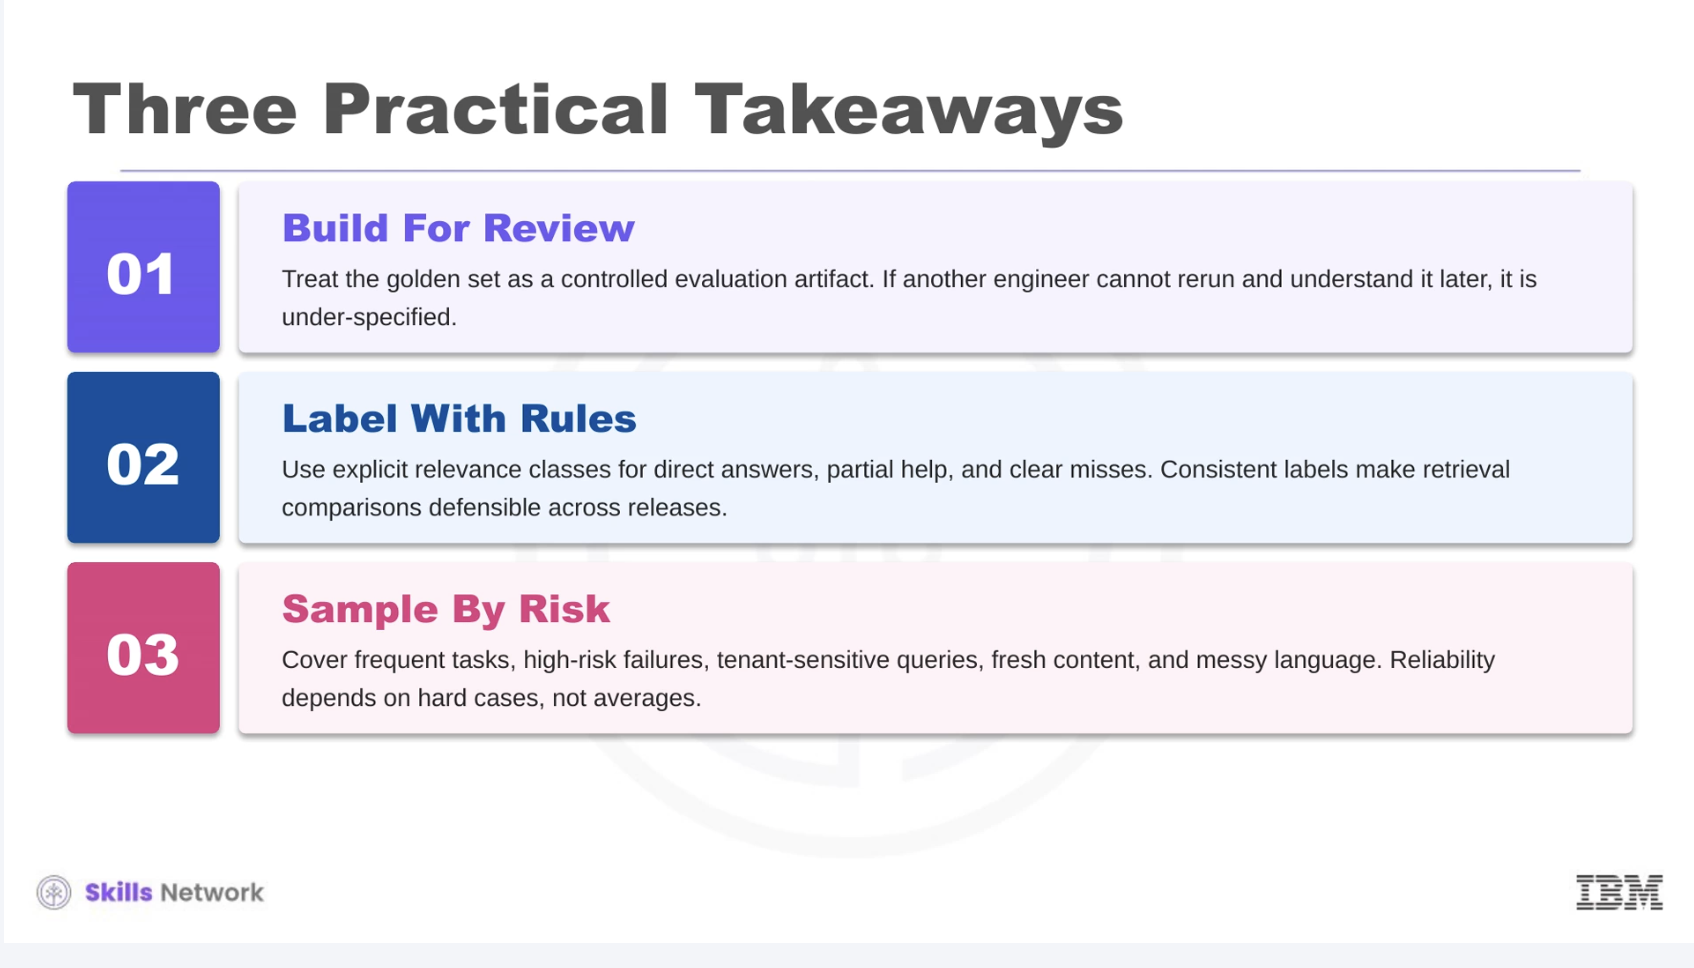


# Retrieval Metrics: Recall@k, Precision@k, MRR & Coverage

> 💡 **Core lesson:** Together, these four metrics are the **evidence layer** for evaluating retrieval. Understand what each metric is telling you first; don't memorize the formulas mechanically yet.

---

## 0. The Four Metrics

The entire chapter revolves around four metrics:

| # | Metric | Question it answers |
|---|---|---|
| 1 | **Recall@k** | Did we retrieve enough relevant information? |
| 2 | **Precision@k** | How much of what we retrieved is actually relevant? |
| 3 | **MRR** | How early did the first useful result appear? |
| 4 | **Coverage** | Are we testing all the important types of queries/data? |

---

## 1. Recall@k — "Did I miss anything important?"

This is probably the most important one for my RAG system.

### Definition

Recall@k asks:

> Out of all the relevant items that exist, how many did my retriever successfully bring into the top k?

### Formula

$$
\text{Recall@}k = \frac{\text{relevant items retrieved in top } k}{\text{total relevant items}}
$$

### Course example

> Suppose there are **4 relevant chunks** in the corpus, and the retriever finds **2** of them in its top 5.

Then:

$$
\text{Recall@5} = \frac{2}{4} = 0.50
$$

So the retriever found only **50%** of the relevant information.

### Think about my RAG

Suppose the user asks:

> "What is our refund policy for enterprise customers?"

And there are actually **3 relevant chunks**:

```
Chunk A → refund period
Chunk B → enterprise exception
Chunk C → eligibility condition
```

My retriever returns:

| Rank | Chunk | Relevant? |
|---|---|---|
| 1 | A | ✅ |
| 2 | X | ❌ |
| 3 | Y | ❌ |
| 4 | B | ✅ |
| 5 | Z | ❌ |

I retrieved **2 / 3**. So:

$$
\text{Recall@5} = \frac{2}{3} = 0.67
$$

The problem is that **Chunk C never reached the LLM**.

> ⚠️ Even if my LLM is excellent, it **can't use information it never received**.

> 📌 That's why the course describes recall as measuring **missing context**.

---

## 2. Precision@k — "How much garbage did I retrieve?"

Precision looks at the other side.

> Of the k things I retrieved, how many were actually relevant?

### Formula

$$
\text{Precision@}k = \frac{\text{relevant items retrieved in top } k}{k}
$$

Using the same example:

```
2 relevant
5 retrieved
```

Therefore:

$$
\text{Precision@5} = \frac{2}{5} = 0.40
$$

So **60%** of my retrieved chunks were **noise**.

### The difference is VERY important

| Metric | Question | Simpler |
|---|---|---|
| **Recall** | "Did I get enough of the important stuff?" | **Missing** information |
| **Precision** | "Is the stuff I got mostly important?" | **Unnecessary** information |

> 💡 The course explicitly frames this as: **Recall tells you what you missed. Precision tells you what you polluted the top results with.**

Same numerator, different denominator:

```
                relevant items retrieved in top k
Recall@k    =  ---------------------------------   ← divide by ALL relevant items that exist
                    total relevant items

                relevant items retrieved in top k
Precision@k =  ---------------------------------   ← divide by what I RETRIEVED
                            k
```

---

## Recall vs Precision in RAG

This is where it becomes useful for my architecture.

Imagine my retriever returns **10 chunks**.

### System A

```
10 retrieved
9 relevant
1 irrelevant
```

$$
\text{Precision@10} = 0.90
$$

**Great precision.**

But suppose there were actually **20 relevant chunks** in the corpus:

$$
\text{Recall@10} = \frac{9}{20} = 0.45
$$

So despite having very clean results, I'm **missing more than half** of the relevant information.

### System B

```
10 retrieved
6 relevant
4 irrelevant
```

$$
\text{Precision@10} = 0.60
$$

**Looks worse.**

But suppose there were only **7 relevant chunks** total:

$$
\text{Recall@10} = \frac{6}{7} = 0.86
$$

Now I'm retrieving much more of the required evidence.

### Side by side

| | System A | System B |
|---|---|---|
| Retrieved | 10 | 10 |
| Relevant retrieved | 9 | 6 |
| Total relevant in corpus | 20 | 7 |
| **Precision@10** | **0.90** ✅ | 0.60 |
| **Recall@10** | 0.45 | **0.86** ✅ |

> ⚠️ This is why I **can't judge a retriever using precision alone or recall alone**. The course explicitly warns that different applications have different tradeoffs.

---

## 3. What Is k?

I've asked about this before, so let's make it crystal clear.

> 💡 **k** simply means: **How many top results are we looking at?**

For example:

```
top_k = 5
```

means:

> Give me the top 5 retrieved chunks.

So:

| Notation | Meaning |
|---|---|
| `Recall@5` | Recall calculated using the top **5** results |
| `Precision@10` | Precision calculated using the top **10** results |

And **k matters** because top-3, top-10 and top-50 are **different retrieval behaviors**.

> 📌 The course says k should be chosen based on how my **actual application** works — reranker depth, context budget, UI, etc.

---

## 4. MRR — "How quickly did I find something useful?"

Now we move from **how much** information we found to **where** it appeared in the ranking.

> 💡 **MRR = Mean Reciprocal Rank.**

The question is:

> Where was the **first** relevant result?

Suppose:

| Rank | Result |
|---|---|
| 1 | irrelevant |
| 2 | **relevant** ← first relevant |
| 3 | irrelevant |
| 4 | relevant |

The first relevant result is **rank 2**. Its reciprocal rank is:

$$
\frac{1}{2} = 0.5
$$

| First relevant result at | Reciprocal rank |
|---|---|
| Rank 1 | 1/1 = **1.0** |
| Rank 2 | 1/2 = **0.5** |
| Rank 4 | 1/4 = **0.25** |
| No relevant result | **0** |

Then **average these values across queries**.

### Simple mental model

> 💡 **MRR = How quickly does useful information show up?**

The course literally describes it as essentially a **"stopwatch for the first useful result."**

### Why MRR is different from Recall

Suppose both systems retrieve the same relevant chunks.

| Rank | Retriever A | Retriever B |
|---|---|---|
| 1 | Relevant ✅ | irrelevant |
| 2 | irrelevant | irrelevant |
| 3 | irrelevant | irrelevant |
| 4 | Relevant ✅ | Relevant ✅ |
| **First relevant** | rank 1 | rank 4 |
| **MRR** | **1** | **0.25** |

Both might eventually retrieve relevant information. But **Retriever A gets useful information to the LLM much earlier** in the ranking.

> 📌 That's what MRR captures.

### ⚠️ Important limitation of MRR

This is a big one.

> ⚠️ **MRR only cares about the first relevant result.**

| Rank | Retriever A | Another retriever |
|---|---|---|
| 1 | Relevant ✅ | Relevant ✅ |
| 2 | irrelevant | Relevant ✅ |
| 3 | irrelevant | Relevant ✅ |
| 4 | irrelevant | Relevant ✅ |
| 5 | irrelevant | irrelevant |
| **MRR** | **1.0** | **1.0** |

Retriever A looks excellent with MRR = 1.0 — but it **missed all the other relevant chunks**. The other retriever also gets MRR = 1.0.

So MRR **doesn't tell us about the additional relevant results**.

> 📌 That's why the course says MRR should be used **alongside** recall and precision, **not instead of** them.

---

## 5. Coverage — "Are we testing the right things?"

This one is slightly different.

Coverage isn't really asking:

> "How good is my ranking?"

It's asking:

> "Did my evaluation actually test the situations that matter in production?"

For example, suppose my RAG evaluation has:

| Language | Queries |
|---|---|
| English | 950 |
| Spanish | 30 |
| German | 20 |
| **Total** | **1000** |

My overall recall might look amazing. But maybe my **Spanish retrieval is terrible**.

> ⚠️ **My average hides it.**

> 💡 The course calls coverage an **evaluation completeness metric**.

### What should I split coverage by?

The course specifically identifies:

| Dimension | Examples |
|---|---|
| Query intent | policy lookup, troubleshooting, fact lookup |
| Document type | tickets, PDFs, wikis, tables, API docs |
| Tenant | — |
| Corpus segment | recent vs archived |
| Language/region | — |
| **Security boundary** | public, internal, restricted |

This last one is particularly relevant to my **secure RAG** work.

I don't want:

```
Overall recall = 0.92
```

and then discover:

```
Restricted documents:
recall = 0.51
```

because my overall benchmark mostly contained public documents.

---

## Put All Four Together

Here's the mental model to remember:

| Metric | Question |
|---|---|
| **Recall@k** | Did I retrieve enough relevant information? |
| **Precision@k** | How much of my retrieved information is relevant? |
| **MRR** | How early did the first useful result appear? |
| **Coverage** | Did I test all the important production scenarios? |

Or even simpler:

```
Recall     → Missing stuff?
Precision  → Garbage stuff?
MRR        → Useful stuff arriving late?
Coverage   → Are we testing the right stuff?
```

---

## How This Connects to My RAG Architecture

Imagine my retrieval pipeline:

```
User Query
    ↓
Retriever
    ↓
Top-k chunks
    ↓
Reranker
    ↓
LLM
```

I can evaluate the retriever with:

- Recall@k
- Precision@k
- MRR

And then ask:

```
Does this evaluation represent production?
        ↓
Coverage
```

So a good evaluation doesn't just say:

> "Our recall is 0.87."

It should say something like:

```
Overall recall@10     = 0.87
MRR                    = 0.71
Precision@10           = 0.64

Tenant A recall        = 0.92
Tenant B recall        = 0.84

Policy queries         = 0.91
Troubleshooting        = 0.78

Public docs            = 0.94
Restricted docs        = 0.72
```

> 📌 That is actually **useful engineering evidence**.

The course's practical checklist also emphasizes:

1. **Freezing** the corpus / model / chunking / filter / retriever configuration
2. Calculating **per-query metrics first**
3. Then **slicing** results by operationally important categories

---

## 🔴 One Thing to Lock Into My Brain

For my future RAG security architecture:

> ⚠️ **A healthy latency number does NOT mean retrieval is healthy.**

**CareBridge** was a perfect example:

| Metric | Before | After | Change |
|---|---|---|---|
| Latency | 780 ms | 812 ms | barely moved |
| Recall | 0.86 | 0.71 | ⬇️ dropped |
| MRR | 0.62 | 0.48 | ⬇️ dropped |

> 📌 That's exactly why **retrieval metrics are necessary**.

And don't memorize the formulas mechanically yet. **Understand what each metric is telling you first.**

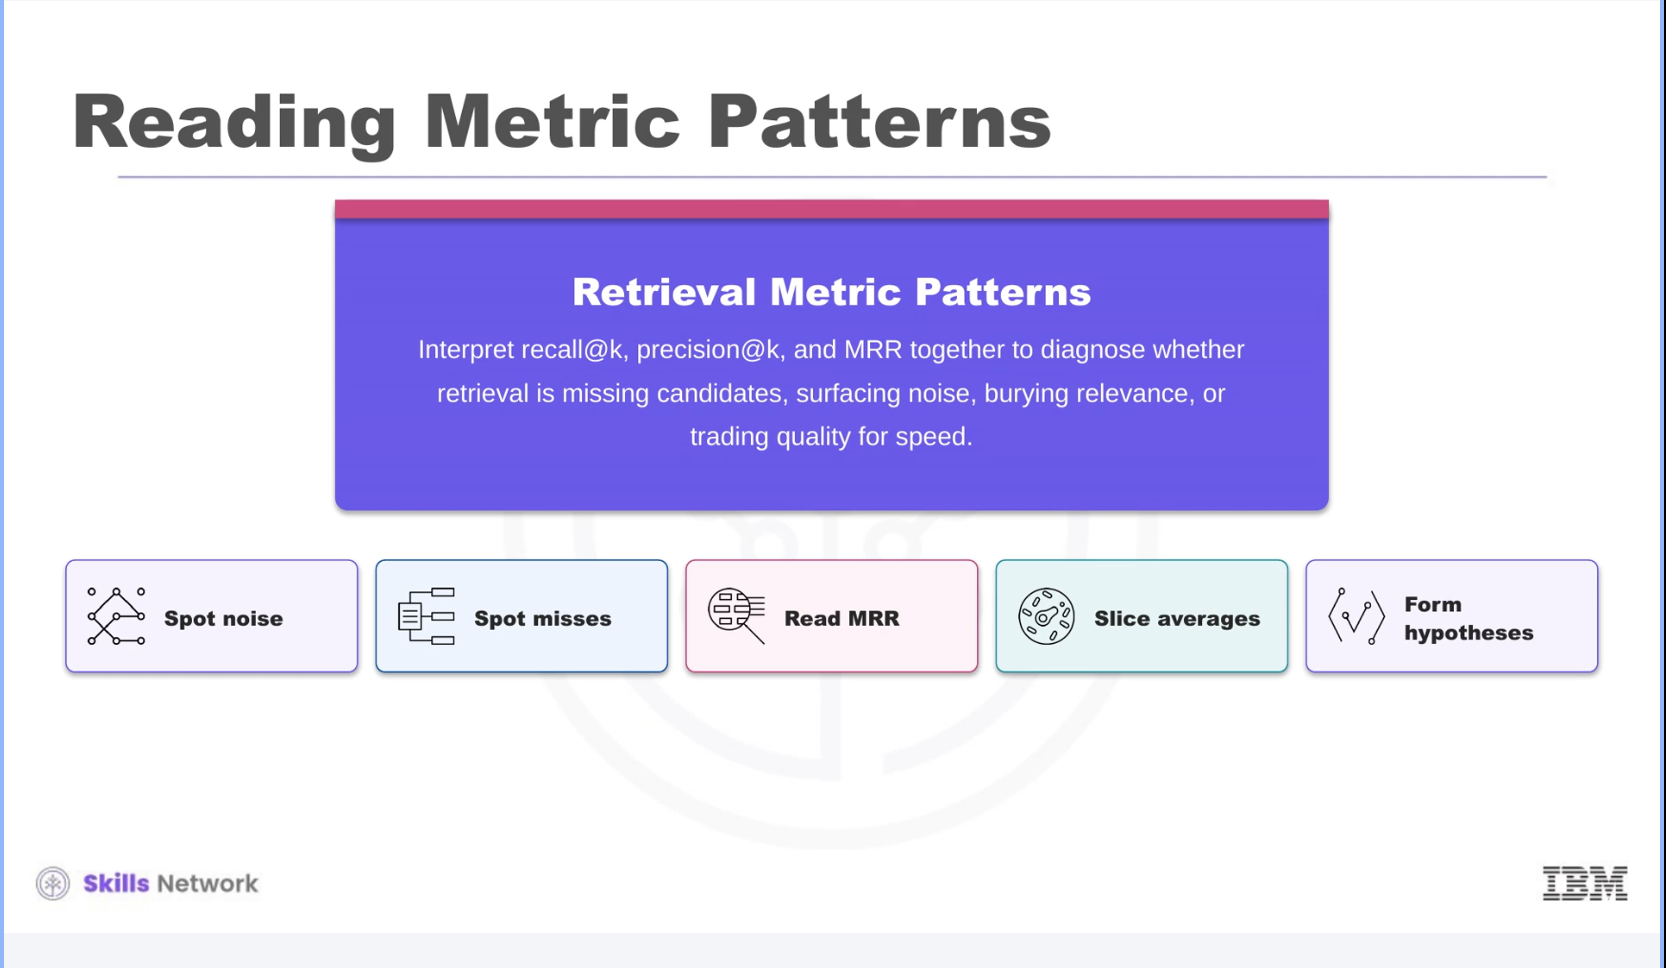
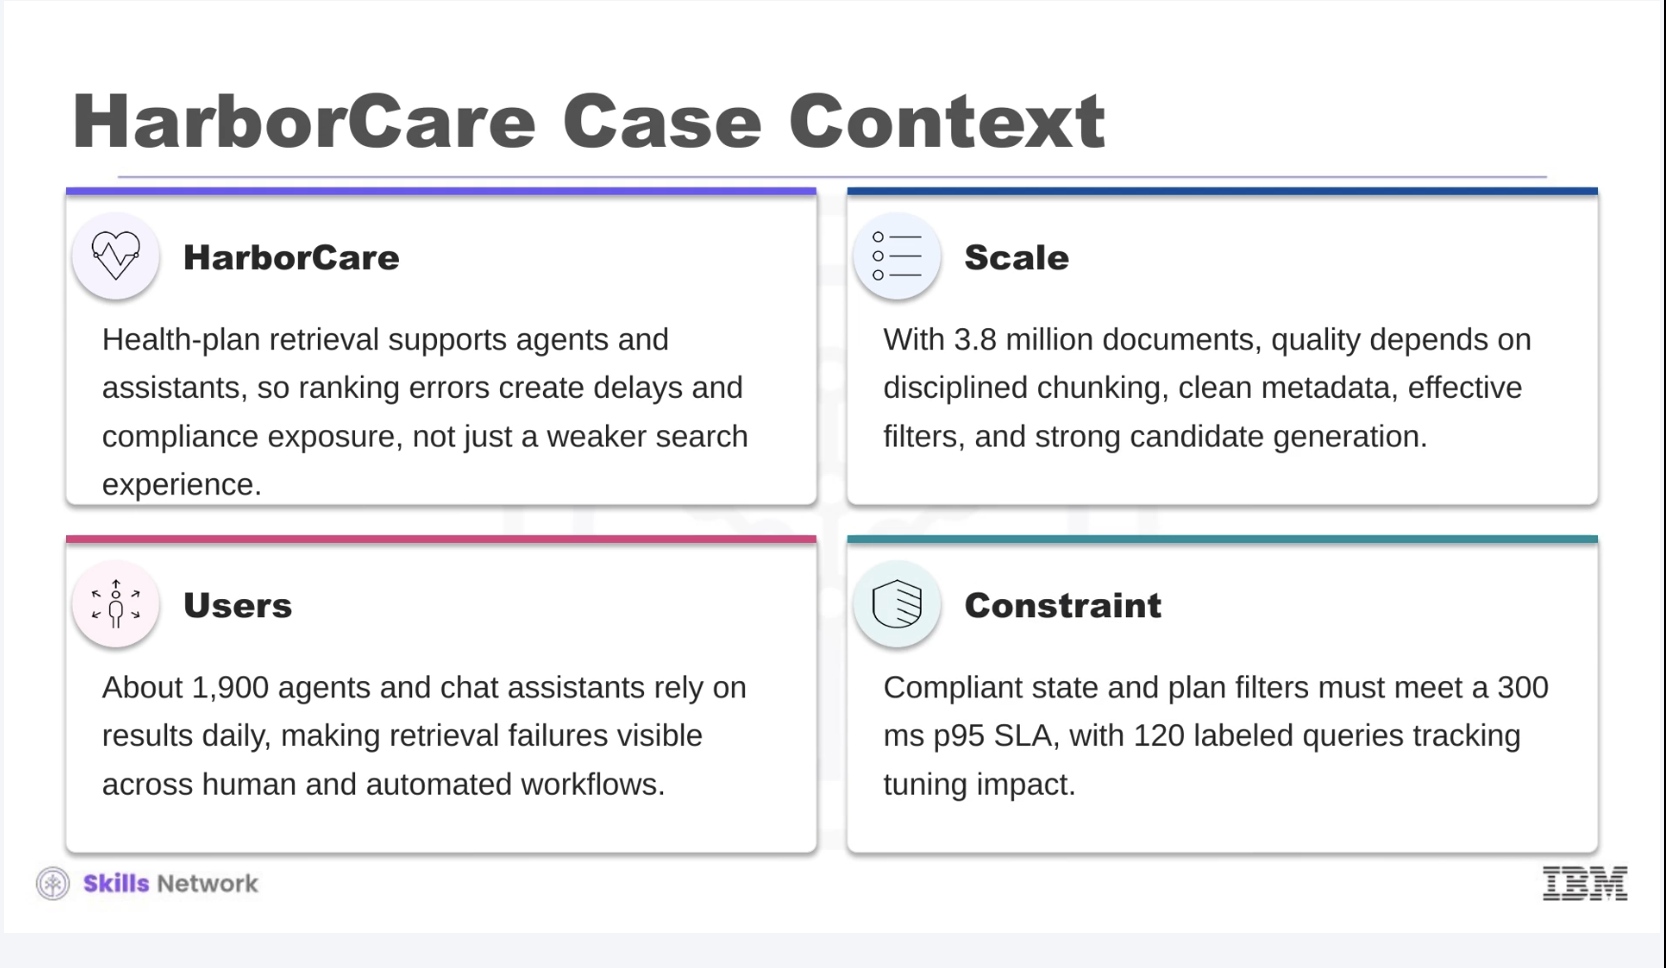
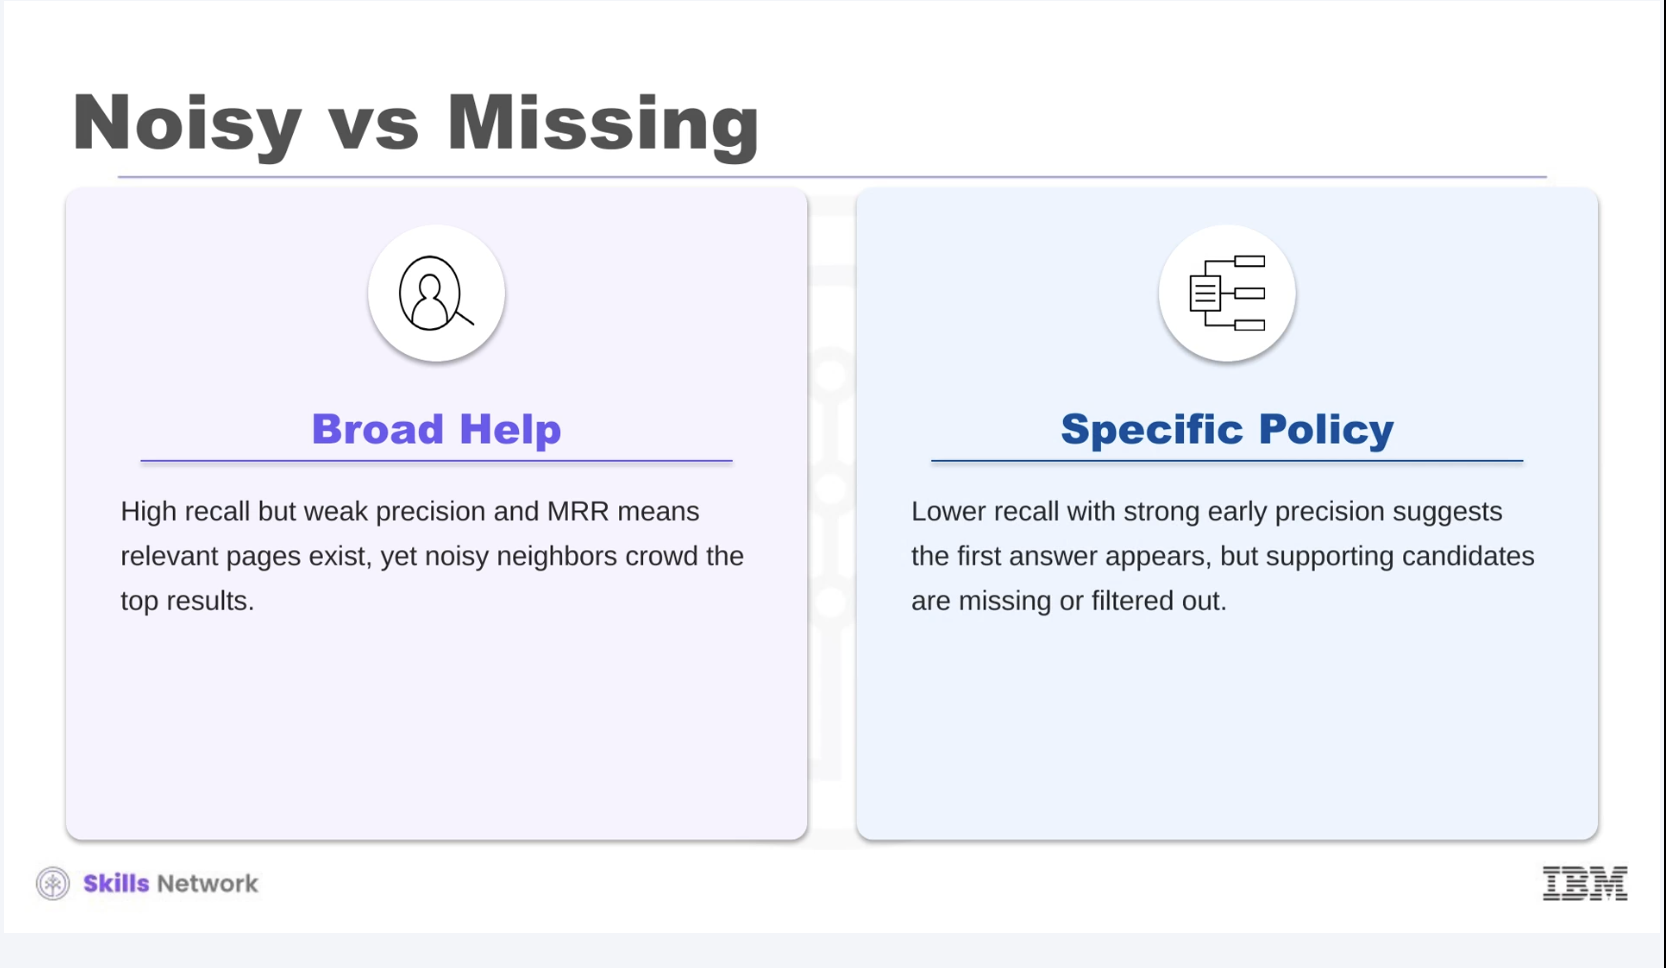
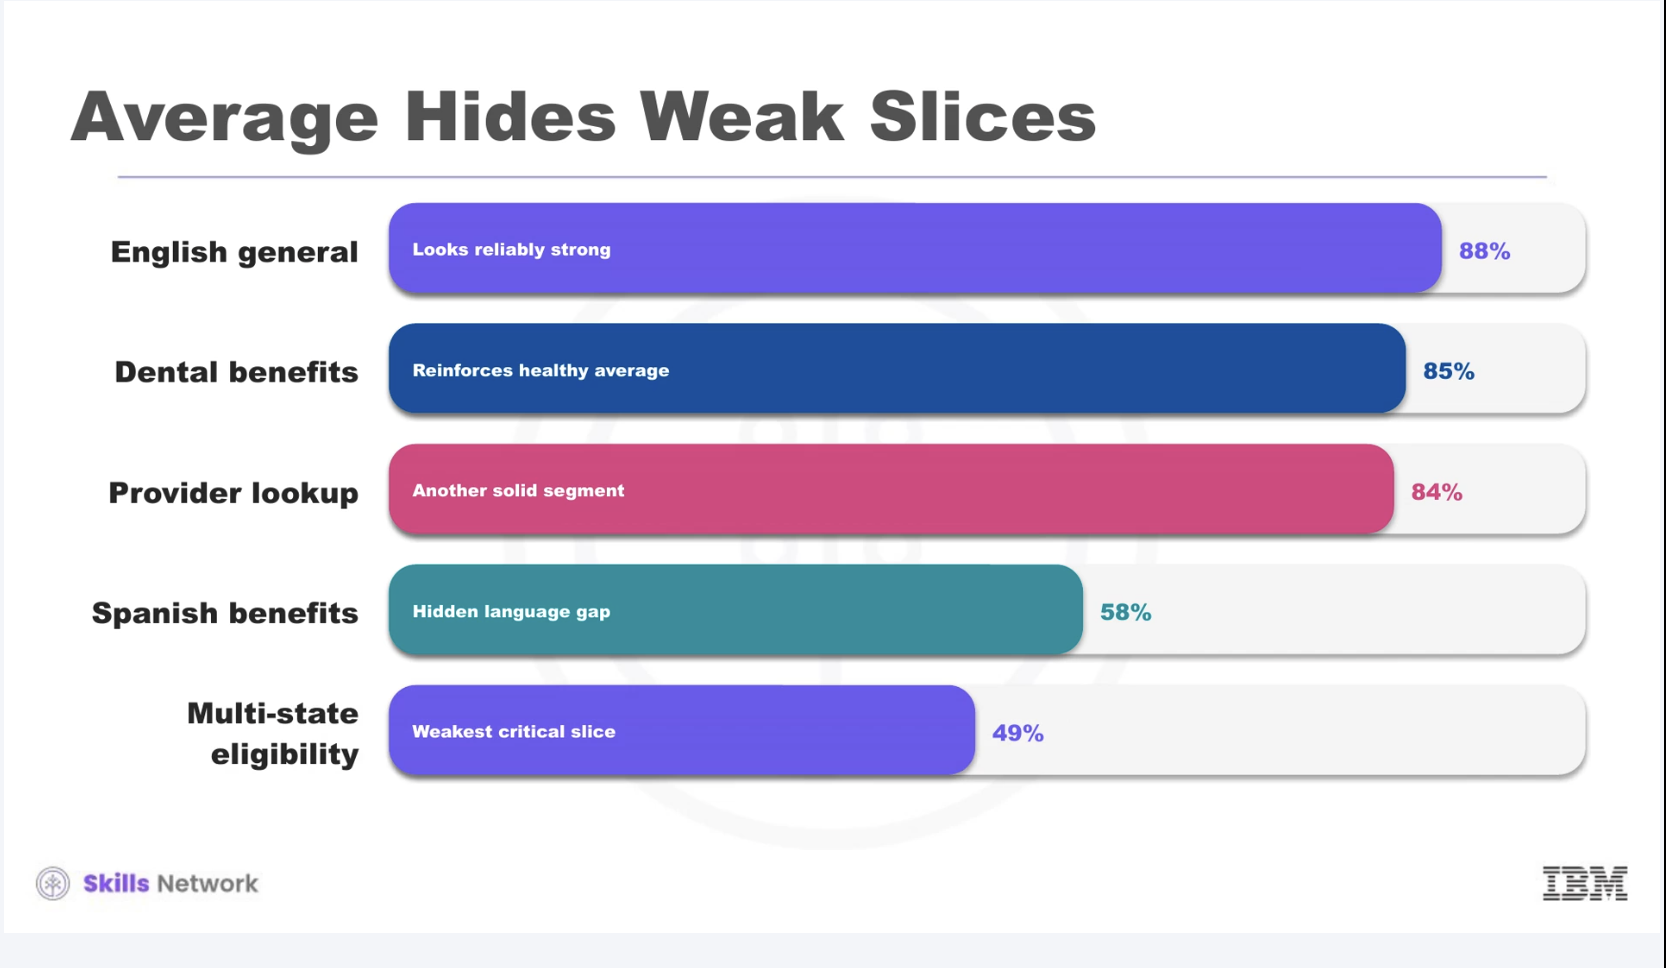
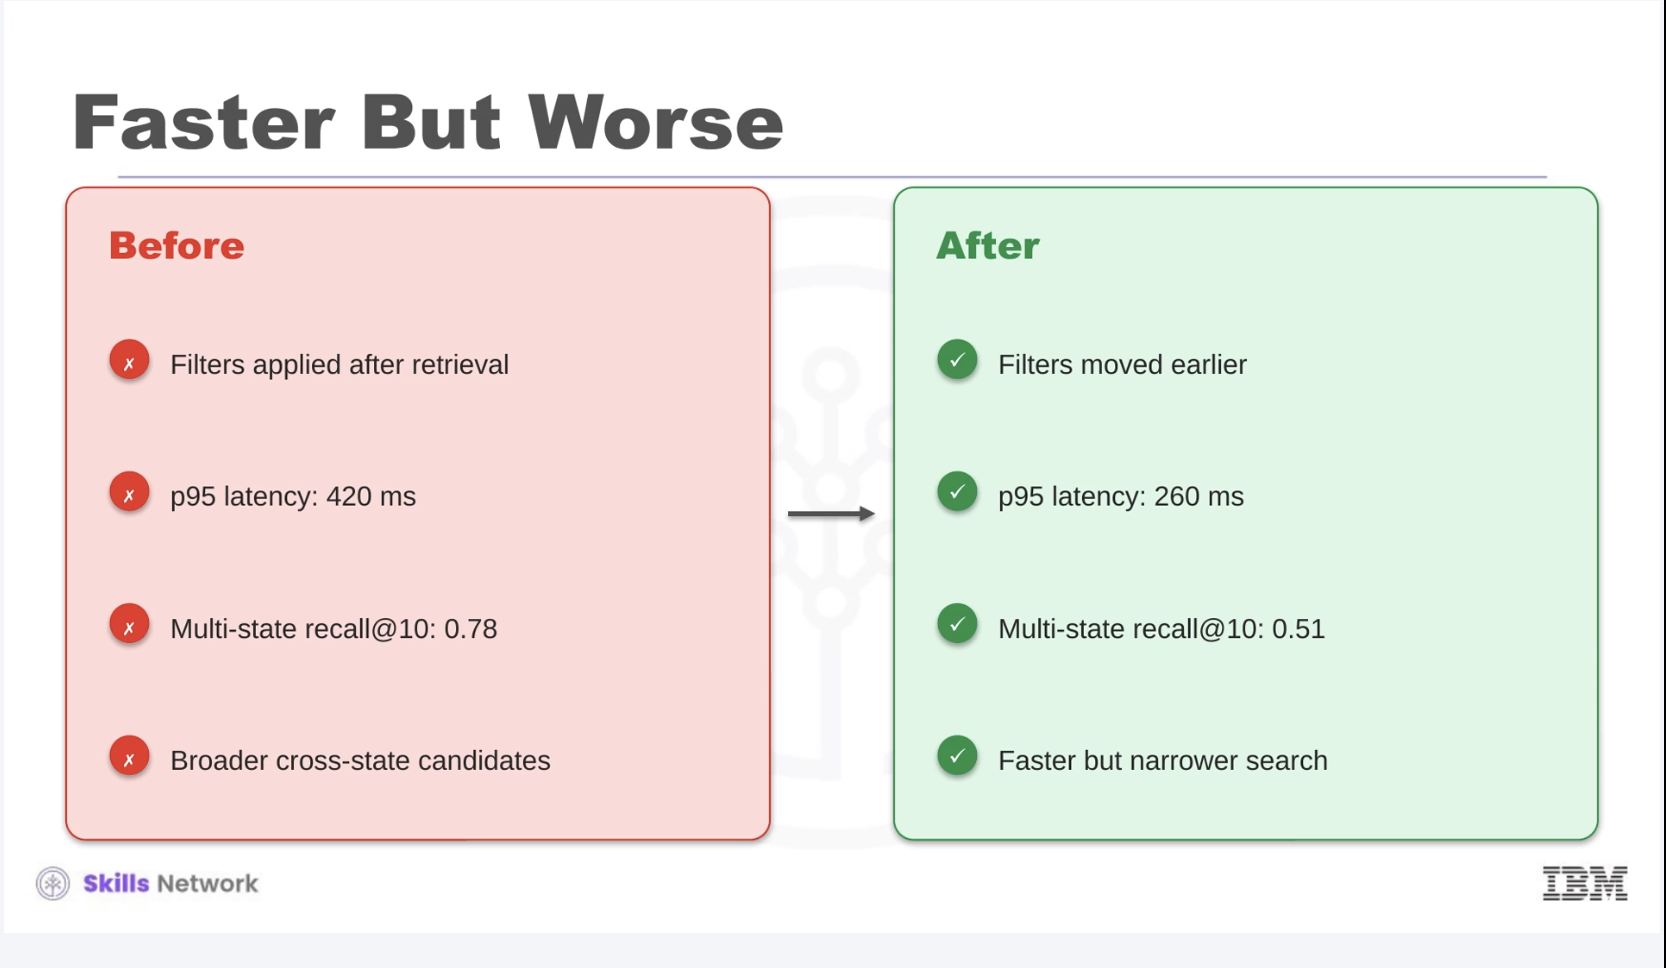
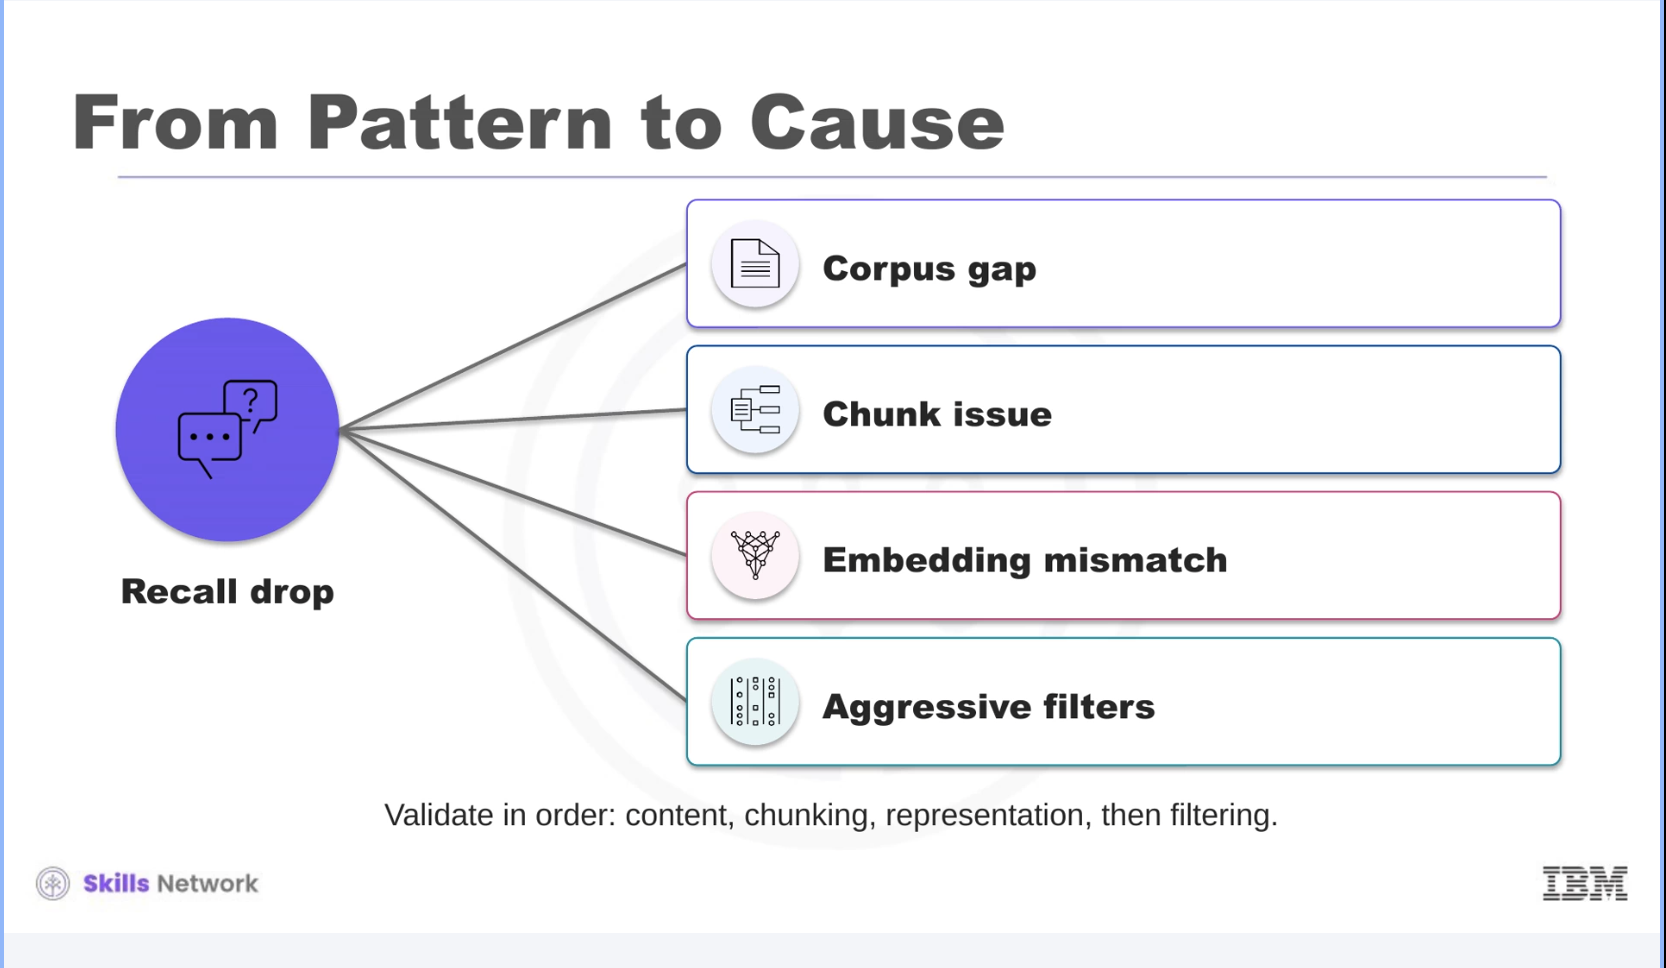
